In [1]:
import re
import os
import sys
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display

try:
    import torch
except Exception:
    torch = None

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet, stopwords
from nltk import pos_tag
from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOP_WORDS

import gensim
from gensim import corpora
from gensim.models import CoherenceModel

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans

from bertopic import BERTopic

# Robust import because some environments complain about bertopic.vectorizers
try:
    from bertopic.vectorizers import ClassTfidfTransformer
except ImportError:
    from bertopic.vectorizers._ctfidf import ClassTfidfTransformer


# ==========================================
# Identity reducer
# We use this instead of UMAP because our pipeline uses TF-IDF/SVD embeddings
# ==========================================

class IdentityDimensionalityReducer:
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X

    def fit_transform(self, X, y=None):
        return X

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)

    for p in [start.resolve()] + list(start.resolve().parents):
        if (p / "csvs").exists() and (p / "markdown").exists():
            return p

    return start.resolve()


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


try:
    import scripts.text_mining_utils as tmu
except ImportError:
    tmu = None
    print("Warning: scripts.text_mining_utils not found. Continuing without it.")


CSVS_CHUNKED = PROJECT_ROOT / "csvs" / "chunked"
CHUNKS_ALL = CSVS_CHUNKED / "chunks_all.csv"

PIPELINE_DIR = (
    PROJECT_ROOT
    / "progress"
    / "topic_modelling"
    / "bertopic"
    / "sentiment"
)


OUT_DIR = PIPELINE_DIR / "output"
IMG_DIR = PIPELINE_DIR / "img"

OUT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 160)


NLTK_DATA_DIR = PROJECT_ROOT / "data" / "auto"
NLTK_DATA_DIR.mkdir(parents=True, exist_ok=True)

if str(NLTK_DATA_DIR) not in nltk.data.path:
    nltk.data.path.append(str(NLTK_DATA_DIR))

nltk_packages = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
]

for package in nltk_packages:
    try:
        nltk.download(package, download_dir=str(NLTK_DATA_DIR), quiet=True)
    except Exception as e:
        print(f"Warning: NLTK package not available: {package} ({e})")


print("Project root:", PROJECT_ROOT)
print("Input chunks file:", CHUNKS_ALL)
print("Pipeline folder:", PIPELINE_DIR)
print("Output folder:", OUT_DIR)
print("Image folder:", IMG_DIR)
print("Utility module:", None if tmu is None else tmu.__name__)
print("BERTopic import: OK")
print("ClassTfidfTransformer import: OK")

Project root: /home/nsirim/Github/mscdsa/msc
Input chunks file: /home/nsirim/Github/mscdsa/msc/csvs/chunked/chunks_all.csv
Pipeline folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/sentiment
Output folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/sentiment/output
Image folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/sentiment/img
Utility module: scripts.text_mining_utils
BERTopic import: OK
ClassTfidfTransformer import: OK


In [2]:
# ==========================================
# Step 1: Load sentiment chunks
# ==========================================

CORPUS_FILTER = "sentiment"

required_columns = {
    "doc_id",
    "corpus",
    "source_type",
    "country",
    "heading_context",
    "chunk_text",
}


# ==========================================
# Helper functions for text construction
# Same logic as policy pipeline
# ==========================================

def safe_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def normalise_heading_text(heading):
    heading = safe_text(heading)
    heading = re.sub(r"\s+", " ", heading)
    heading = re.sub(r"^\d+(\.\d+)*\s+", "", heading)
    return heading.strip()


def build_original_heading_context_chunk_text(row):
    heading = normalise_heading_text(row["heading_context"])
    chunk_text = safe_text(row["chunk_text"])

    if heading and chunk_text.lower().startswith(heading.lower()):
        return chunk_text

    return f"{heading} {chunk_text}".strip()


def build_bertopic_source_text(row):
    heading = normalise_heading_text(row["heading_context"])
    chunk_text = safe_text(row["chunk_text"])

    if not heading:
        return chunk_text

    if chunk_text.lower().startswith(heading.lower()):
        return chunk_text

    heading_word_count = len(heading.split())

    if heading_word_count <= 12:
        return f"{heading}. {chunk_text}"

    return chunk_text


# ==========================================
# Optional artifact removal
# Same spirit as policy pipeline
# ==========================================

def remove_document_artifact_chunks(dataframe):
    artifact_heading_pattern = re.compile(
        r"^(contents|table of contents|acknowledgements?|acknowledgments?|"
        r"acronyms?|abbreviations?|illustrations?|bibliography|references|"
        r"web sources|about the author|about the authors|authors?|cover|"
        r"copyright|appendix|annex|figures?|tables?|foreword|preface)$",
        re.IGNORECASE,
    )

    artifact_text_pattern = re.compile(
        r"(table of contents|copyright|all rights reserved|isbn|bibliography|"
        r"references|web sources|cover photo|printed in|printed by|"
        r"designed and printed|directorate of communications|creative commons|"
        r"open access repository|legal status of any country|frontiers or boundaries|"
        r"does not imply the expression|shutterstock|doi\.org|creativecommons|"
        r"attribution-sharealike)",
        re.IGNORECASE,
    )

    heading_mask = (
        dataframe["heading_context"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.match(artifact_heading_pattern)
    )

    text_mask = (
        dataframe["chunk_text"]
        .fillna("")
        .astype(str)
        .str[:900]
        .str.contains(artifact_text_pattern, regex=True, na=False)
    )

    artifact_mask = heading_mask | text_mask

    return dataframe.loc[~artifact_mask].copy(), int(artifact_mask.sum())


# ==========================================
# Load and prepare sentiment dataframe
# ==========================================

try:
    # Use the project CSV path first; fall back to a local chunks_all*.csv if needed.
    input_chunks_file = CHUNKS_ALL

    if not input_chunks_file.exists():
        # Fallback is useful when the notebook is run outside the project folder.
        fallback_dirs = [PROJECT_ROOT, Path.cwd(), Path("/mnt/data")]
        local_candidates = []

        for folder in fallback_dirs:
            if folder.exists():
                local_candidates.extend(sorted(folder.glob("chunks_all*.csv")))

        if local_candidates:
            input_chunks_file = local_candidates[0]

    print("Input file:", input_chunks_file)

    df = pd.read_csv(input_chunks_file, encoding="utf-8-sig")

    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

    # Keep only sentiment corpus
    df = df[df["corpus"] == CORPUS_FILTER].copy()

    # Normalise basic text columns
    df["heading_context"] = df["heading_context"].fillna("").astype(str)
    df["chunk_text"] = df["chunk_text"].fillna("").astype(str)

    # Keep metadata needed later
    df["source_type"] = df["source_type"].fillna("unknown").astype(str)

    if "synthetic_type" not in df.columns:
        df["synthetic_type"] = "not_synthetic"
    else:
        df["synthetic_type"] = df["synthetic_type"].fillna("not_synthetic").astype(str)

    # Remove empty chunks
    df = df[df["chunk_text"] != "N/A"].copy()
    df = df[df["chunk_text"].str.strip() != ""].copy()

    # Remove obvious document artifacts
    df, removed_artifact_chunks = remove_document_artifact_chunks(df)

    # Build the same source text fields used in the policy pipeline
    df["heading_context_chunk_text"] = df.apply(
        build_original_heading_context_chunk_text,
        axis=1,
    )

    df["bertopic_source_text"] = df.apply(
        build_bertopic_source_text,
        axis=1,
    )

    df = df[df["bertopic_source_text"].str.len() > 0].copy()

    # Mark synthetic rows using source_type only.
    df["is_synthetic"] = (
        df["source_type"]
        .fillna("")
        .astype(str)
        .str.lower()
        .eq("synthetic")
    )

    # Keep synthetic_type metadata readable.
    df.loc[df["is_synthetic"], "synthetic_type"] = "synthetic"
    df.loc[~df["is_synthetic"], "synthetic_type"] = "not_synthetic"

    # Split for later stages
    original_df = df[~df["is_synthetic"]].copy()
    synthetic_df = df[df["is_synthetic"]].copy()

    print(f"Loaded sentiment chunks: {len(df)}")
    print(f"Original sentiment chunks: {len(original_df)}")
    print(f"Synthetic sentiment chunks: {len(synthetic_df)}")
    print(f"Removed document-artifact chunks: {removed_artifact_chunks}")

    print("\nChunks by source type:")
    print(df["source_type"].value_counts(dropna=False))

    print("\nChunks by synthetic type:")
    print(df["synthetic_type"].value_counts(dropna=False))

    print("\nChunks by country:")
    print(df["country"].value_counts(dropna=False))

    if "filename" in df.columns:
        print("\nTop sentiment files:")
        print(df["filename"].value_counts().head(20))
    else:
        print("\nTop sentiment documents:")
        print(df["doc_id"].value_counts().head(20))

except FileNotFoundError:
    print("Error: chunks_all.csv not found.")
    print("Expected path:", CHUNKS_ALL)
    raise

except Exception as e:
    print(f"Error while loading sentiment chunks: {e}")
    raise

Input file: /home/nsirim/Github/mscdsa/msc/csvs/chunked/chunks_all.csv
Loaded sentiment chunks: 684
Original sentiment chunks: 482
Synthetic sentiment chunks: 202
Removed document-artifact chunks: 64

Chunks by source type:
source_type
original     482
synthetic    202
Name: count, dtype: int64

Chunks by synthetic type:
synthetic_type
not_synthetic    482
synthetic        202
Name: count, dtype: int64

Chunks by country:
country
NaN                    482
synthetic_sentiment    202
Name: count, dtype: int64

Top sentiment files:
filename
AI4T_WP3_D3.3_NR_Ireland.md                                                                                                  108
generative artificial intelligence in secondary education-KJ0125604ENN.md                                                     78
051024_Insights into AI and the youth sector.md                                                                               51
AI_views of youth workers.md                                        

In [3]:
# ==========================================
# Step 2: Stopwords definition
# ==========================================

stop_words = set(SPACY_STOP_WORDS)

try:
    stop_words.update(set(stopwords.words("english")))
except Exception:
    print("Warning: NLTK English stopwords not found. Using spaCy English stopwords only.")

try:
    stop_words.update(set(stopwords.words("french")))
except Exception:
    print("Warning: French stopwords not found.")

document_artifact_stopwords = [
    "pdf", "qxp", "page", "copyright", "reserved",
    "www", "http", "https", "com", "org",
    "figure", "table", "annex", "appendix", "footnote", "endnote",
    "isbn", "bibliography", "citation", "reference", "metadata", "docx",
    "executive summary", "draft", "matrix", "blueprint", "snapshot",
    "chart", "brochure", "fig"
]

legal_structure_stopwords = [
    "section", "chapter", "part", "title", "article", "clause",
    "paragraph", "subparagraph", "schedule", "exhibit", "supplement",
    "addendum", "preamble", "recital", "report",
    "chapitre", "partie", "titre", "paragraphe", "alinea",
    "annexe", "appendice", "expos", "des", "motifs",
    "disposition"
]

legal_boilerplate_stopwords = [
    "coppa", "ferpa", "enact", "bit",
    "herein", "therein", "thereof", "whereof", "hereby",
    "whereby", "hereinafter", "thereafter", "aforementioned",
    "foregoing", "henceforth", "whereto", "whereupon",
    "notwithstanding", "pursuant", "thereto", "thereunder", "hereto",
    "susmentionn", "prcit", "nonobstant", "par drogation",
    "en", "consquence", "eu", "gard", "aux fins",
    "selon", "conformment", "outre", "ladite", "ledit", "dune"
]

policy_action_stopwords = [
    "shall", "must", "may", "might", "could", "would", "should", "will",
    "require", "requires", "required",
    "ensure", "ensures",
    "seek", "seeks", "seeking",
    "establish", "establishes",
    "promote", "promotes", "promoting",
    "maintain", "respect",
    "doit", "devrait", "pourrait", "vouloir",
    "exiger", "requis", "assurer", "garantir",
    "rechercher", "tablir", "promouvoir",
    "maintenir", "respecter"
]

policy_connector_stopwords = [
    "various", "several", "multiple", "certain", "relevant", "appropriate",
    "regarding", "concerning", "involving", "accordance",
    "relate", "relates", "relating",
    "furthermore", "moreover", "therefore", "thus", "hence",
    "however", "although", "including", "etc", "etcetera",
    "concernant", "divers", "plusieurs", "particulier",
    "certain", "aussi", "de plus", "en outre",
    "par consquent", "donc", "ainsi", "cependant",
    "bien que", "notamment", "entre autres", "comme",
    "toute", "tous", "cette", "plus", "leurs"
]

geo_institutional_stopwords = [
    "ireland", "irish", "france", "french", "usa", "america",
    "australia", "australian",
    "country", "nation", "national", "state",
    "government", "federal", "ministry", "department",
    "gouvernement", "ministre", "dtat", "republic",
    "pittsburg", "antioch", "medina", "winterset",
    "sara", "washington", "california", "massachusetts",
    "oregon", "sweden", "unified", "district",
    "commonwealth", "nsw"
]

tech_ai_stopwords = [
    "artificial", "intelligence",
    "ai", "ia", "lia", "dia",
    "genai", "generative",
    "model", "models", "llm",
    "algorithm", "algorithms",
    "machine", "learning",
    "data", "dataset", "datasets",
    "digital", "numrique",
    "computer", "software", "hardware",
    "technology", "technological",
    "platform", "online", "internet", "web", "electronic",
    "tool", "system", "device", "application", "app", "service",
    "broadband", "connectivity", "vendor", "player", "enterprise",
    "artificielle", "gen", "generatif",
    "modle", "modles",
    "apprentissage", "donn",
    "ordinateur", "logiciel", "matriel",
    "technologie", "plateforme", "ligne",
    "ectronique", "outil", "systme", "dispositif",
    "générative", "intelligent",
    "edge", "gpt", "openai", "microsoft", "google",
    "amazon", "meta", "ibm", "nvidia", "intel",
    "gemini", "deepseek", "anthropic", "claude",
    "embedding", "transformer", "natural language",
    "climate change", "ieee", "architecture",
    "chatgtp", "copilot", "kwyk", "technologies",
    "new", "work", "law", "system", "systems", "right",
    "services", "based", "case", "human",
    "generated", "related"
]

education_stopwords = [
    "school", "education", "educational",
    "pupil", "classroom", "learning",
    "teacher", "teachers", "schools",
    "student", "students",
    "post", "primary", "technical",
    "cole", "educatif", "enseignant", "enseignats", "enseignants",
    "professeur", "programme",
    "apprentissage", "enseignement", "formation",
    "établissement", "éducation", "école",
    "élève", "élèves",
    "covid", "showcase", "deliverable"
]

org_name_stopwords = [
    "adam", "mary", "jensen", "abraham", "lincoln",
    "knight", "kim", "guez",
    "oecd", "cbs", "webwise", "cosn", "dlf",
    "scoilnet", "deap", "dne", "men",
    "parliament", "commissioner", "public sector",
    "cipa", "protection act", "oide", "tie", "cpd"
]

generic_noise_stopwords = [
    "like", "everybody", "actually",
    "kid", "employee", "min", "box", "loop",
    "black", "asset", "typical", "era",
    "acquire", "behavioral", "behavioural",
    "revolution", "emission", "talent",
    "billion", "count", "witness", "operator",
    "interim", "resourced", "resourcing",
    "round", "support work", "dashboard",
    "ela", "estonia", "pisa", "perspectives",
    "final", "total", "describe", "visit",
    "original", "sample", "low",
    "answer", "ask", "efficacy",
    "deepen", "enhance",
    "author", "researcher", "mission", "personnel",
    "palo", "alto", "card",
    "use", "lot", "enable", "constituent",
    "session", "policy", "document",
    "member", "organisation", "goal",
    "long term", "desirable",
    "ite", "aied", "australasian",
    "perplexed", "guidetoaiinschools", "nenufsd",
    "dent", "fee", "want", "prof", "stu"
]

date_time_stopwords = [
    "july", "april", "august"
]

policy_corpus_checked_stopwords = [
    "create", "level", "plan", "text", "lesson", "area",
    "assist", "example", "resource", "replace", "available",
    "important", "engage", "provide", "include", "develop",
    "development", "make", "way", "role", "approach", "activity",
    "consider", "consideration", "identify", "understand",
    "understanding", "information", "implementation", "implement",
    "process", "practice", "practices",
    "discussion", "debate", "change",
    "future", "key", "range", "effective", "effectively",
    "access", "issue", "issues", "specific", "general",
    "different", "possible", "stakeholder", "stakeholders",
    "initiative", "initiatives", "committee", "commission",
    "advisory", "program", "civil", "carry", "finding", "find"
]

policy_artifact_checked_stopwords = [
    "author", "authors", "printed", "strasbourg", "cedex",
    "shutterstock", "publishing", "cover", "photo",
    "directorate", "communications"
]

sentiment_source_stopwords = [
    "survey", "surveys", "respondent", "respondents",
    "participant", "participants",
    "interview", "interviews",
    "question", "questions",
    "response", "responses",
    "percentage", "percent", "share",
    "group", "groups", "finding", "findings",
    "study", "studies", "analysis"
]

post_cleaning_generic_stopwords = [
    "être", "avoir", "faire", "peut",
    "tout", "tous", "toute", "toutes",
    "autre", "autres",
    "encore", "déjà", "non", "sans",
    "dont", "cela", "même", "mme",
    "très", "moins", "plus", "souvent",
    "cas", "type", "manière", "fonction", "partir",
    "exemple", "question", "réponse", "résultat",
    "objectif", "contenu", "texte", "image"
]

fragment_stopwords = [
    "ing", "tion", "ment", "ness", "ly",
    "able", "ive", "ent", "ant",
    "ence", "ance",
    "ali", "gue", "rod", "rodr",
    "educa", "evi", "al", "ons", "onal", "effec", 
    "con", "consulta", "prac"
]

sentiment_keep_words = [
    "feel", "feels", "feeling",
    "view", "views",
    "support", "supports", "supported",
    "need", "needs", "needed",
    "challenge", "challenges", "challenging",
    "opportunity", "opportunities",
    "benefit", "benefits", "beneficial",
    "impact", "impacts",
    "concern", "concerns", "concerned",
    "worry", "worried",
    "fear", "fears",
    "risk", "risks",
    "trust", "trusted",
    "confidence", "confident",
    "positive", "negative",
    "safe", "safety", "unsafe",
    "harm", "harms",
    "help", "helps", "helpful",
    "attitude", "attitudes",
    "perception", "perceptions",
    "acceptance", "resistance",
    "anxiety", "optimism", "optimistic",
    "skepticism", "scepticism",
    "doubt", "doubts",
    "young",

    # French sentiment terms
    "positif", "positifs", "positive", "positives",
    "négatif", "négatifs", "négative", "négatives",
    "peur", "crainte", "craintes",
    "risque", "risques",
    "confiance", "méfiance",
    "inquiétude", "inquiétudes",
    "bénéfice", "bénéfices",
    "avantage", "avantages",
    "opportunité", "opportunités",
    "préoccupation", "préoccupations",
    "acceptation", "résistance",
    "optimisme", "pessimisme",
    "doute", "doutes",
]

web_code_artifact_stopwords = [
    "yap",
    "tab", "tabs",
    "function", "functions",
    "opts", "var",
    "clone", "addclass", "removeclass",
    "append", "prepend", "onclick", "href", "src",
    "div", "span", "html", "css", "javascript", "jquery",
    "perams", "dlxwindow", "mdtabsview", "lcon", "porent",
    "refre", "stabs", "guid", "olumnview",
    "content",
    "mdtab", "mdtabs", "sup", "anew", "tal", "mab",
    "del", "active", "tag", "extend", "empty", "cor",
    "ret", "rtcodeparams", "removea", "ection",
    "params", "mode"
]

survey_structure_stopwords = [
    "agree", "strongly",
    "item", "items",
    "merge", "merged",
    "category", "categories",
    "number", "present",
    "questionnaire",
    "baseline", "endline",
    "timeline",
    "codebook", "code", "codes", "coded",
    "indicative", "comment", "comments",
    "responded", "respond", "responding"
]

methodology_stopwords = [
    "facetoface",
    "assign", "assigned",
    "intervention",
    "evaluation",
    "demographic", "demographics",
    "minute", "minutes",
    "pathway",
    "project",
    "principal",
    "textbook",
    "deis"
]

small_final_artifact_stopwords = [
    "issn", "remittance", "remittances",
    "likert", "score", "scores", "mean",
    "retire", "retired",
    "ich", "percentage", "percentages",
    "nfq", "der", "die", "una", "los",
    "true", "kind", "remain"
]

custom_stopword_categories = [
    document_artifact_stopwords,
    legal_structure_stopwords,
    legal_boilerplate_stopwords,
    policy_action_stopwords,
    policy_connector_stopwords,
    geo_institutional_stopwords,
    tech_ai_stopwords,
    education_stopwords,
    org_name_stopwords,
    generic_noise_stopwords,
    date_time_stopwords,
    policy_corpus_checked_stopwords,
    policy_artifact_checked_stopwords,
    sentiment_source_stopwords,
    web_code_artifact_stopwords,
    survey_structure_stopwords,
    methodology_stopwords,
    post_cleaning_generic_stopwords,
    fragment_stopwords,
    small_final_artifact_stopwords
]



custom_stopwords = set()

for category in custom_stopword_categories:
    custom_stopwords.update(category)

stop_words.update(custom_stopwords)

actor_keep_words = [
    "teacher", "teachers",
    "student", "students",
    "learner", "learners",
    "staff",
    "educator", "educators",
    "youth",
    "young",
    "people",
    "child", "children",
    "parent", "parents",
    "worker", "workers"
]

keep_words = set(sentiment_keep_words) | set(actor_keep_words)

stop_words.difference_update(keep_words)

print(f"Stopwords loaded: {len(stop_words)}")
print(f"Sentiment terms protected: {len(sentiment_keep_words)}")
print(f"Actor terms protected: {len(actor_keep_words)}")

Stopwords loaded: 1200
Sentiment terms protected: 89
Actor terms protected: 18


In [4]:
# ==========================================
# Step 3: Cleaning and preprocessing helpers
# ==========================================

lemmatizer = WordNetLemmatizer()

extra_french_stopwords = {
    "la", "le", "les", "de", "un", "une", "des", "du", "au", "aux",
    "ce", "cet", "cette", "ces", "je", "me", "te", "se", "ne",
    "que", "qui", "quoi", "dont", "dans", "pour", "par", "sur",
    "avec", "sans", "plus", "moins", "tres", "très", "pas",
    "tout", "tous", "toute", "toutes", "autre", "autres",
    "cela", "meme", "même", "encore"
}

stop_words.update(extra_french_stopwords)

# Keep sentiment-bearing words protected after adding extra French stopwords
stop_words.difference_update(keep_words)


def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    if treebank_tag.startswith("V"):
        return wordnet.VERB
    if treebank_tag.startswith("N"):
        return wordnet.NOUN
    if treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


def has_non_ascii(token):
    return any(ord(char) > 127 for char in token)


def clean_text(text):
    text = str(text).lower()

    text = text.replace("’", "'").replace("‘", "'").replace("`", "'")
    text = text.replace("guillemetleft", " ")
    text = text.replace("guillemetright", " ")

# ==========================================
# OCR and accent repair dictionary
# Apply before tokenisation
# ==========================================

    ocr_fixes = {
        r"\blve\b": "élève",
        r"\blves\b": "élèves",
        r"\bducation\b": "éducation",
        r"\bducatif\b": "éducatif",
        r"\bducative\b": "éducative",
        r"\btablissement\b": "établissement",
        r"\btablissements\b": "établissements",
        r"\bvaluation\b": "évaluation",
        r"\bvaluer\b": "évaluer",
        r"\btrs\b": "très",
        r"\blment\b": "élément",
        r"\blments\b": "éléments",

        # French sentiment / public-opinion OCR repairs
        r"\bngatif\b": "négatif",
        r"\bngatifs\b": "négatifs",
        r"\bngative\b": "négative",
        r"\bngatives\b": "négatives",
        r"\brpondant\b": "répondant",
        r"\brpondants\b": "répondants",
        r"\brponse\b": "réponse",
        r"\brponses\b": "réponses",
        r"\bfranais\b": "français",
        r"\bfranaise\b": "française",
        r"\bfranaises\b": "françaises",
        r"\bsocit\b": "société",
        r"\bsocits\b": "sociétés",
        r"\bdveloppement\b": "développement",
        r"\beuropen\b": "européen",
        r"\beuropenne\b": "européenne",
        r"\beuropens\b": "européens",
        r"\beuropennes\b": "européennes",
        r"\bnumrique\b": "numérique",
        r"\bgnratif\b": "génératif",
        r"\bgnrative\b": "générative",
        r"\bgnratives\b": "génératives",
        r"\bsystme\b": "système",
        r"\bsystmes\b": "systèmes",
    }


    for pattern, replacement in ocr_fixes.items():
        text = re.sub(pattern, replacement, text)

    french_contractions = {
        r"\bl'": "la ",
        r"\bd'": "de ",
        r"\bc'": "ce ",
        r"\bj'": "je ",
        r"\bm'": "me ",
        r"\bt'": "te ",
        r"\bs'": "se ",
        r"\bn'": "ne ",
        r"\bqu'": "que ",
        r"\blorsqu'": "lorsque ",
        r"\bpuisqu'": "puisque ",
        r"\bquoiqu'": "quoique ",
        r"\bjusqu'": "jusque ",
        r"\baujourd'": "aujourd ",
    }

    for pattern, replacement in french_contractions.items():
        text = re.sub(pattern, replacement, text)

    text = re.sub(r"\S*@\S*\s?", " ", text)
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\[\d+\]", " ", text)
    text = re.sub(r"\(\s*see\s+[^\)]+\)", " ", text)
    text = re.sub(r"footnote\s*\d+", " ", text)

    text = re.sub(r"\b\d+[\w-]*\b", " ", text)
    text = re.sub(r"\b(amp|lt|gt|quot|nbsp)\b", " ", text)

    text = re.sub(r"[^a-zàâäéèêëïîôùûüÿçæœ\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()

    cleaned_tokens = []

    for token in tokens:
        token = token.strip("-")

        if not token:
            continue

        if len(token) <= 2:
            continue

        if re.fullmatch(r"[a-zàâäéèêëïîôùûüÿçæœ]-[a-zàâäéèêëïîôùûüÿçæœ]", token):
            continue

        cleaned_tokens.append(token)

    return cleaned_tokens


def remove_stopwords(tokens):
    filtered_tokens = []

    for token in tokens:
        token = token.strip("_-")

        if not token:
            continue

        parts = token.split("_")

        if len(token) <= 2:
            continue

        if token in stop_words:
            continue

        if all(part in stop_words for part in parts):
            continue

        if any(len(part) <= 2 for part in parts):
            continue

        filtered_tokens.append(token)

    return filtered_tokens


def lemmatize_tokens(tokens):
    if not tokens:
        return []

    try:
        pos_tags = pos_tag(tokens)
    except Exception:
        # If the NLTK tagger is unavailable, keep tokens unchanged.
        # This avoids breaking the pipeline in restricted environments.
        return tokens

    lemmatized = []

    for token, pos in pos_tags:
        if "_" in token:
            lemmatized.append(token)
        elif has_non_ascii(token):
            lemmatized.append(token)
        else:
            try:
                lemmatized.append(
                    lemmatizer.lemmatize(token, get_wordnet_pos(pos))
                )
            except Exception:
                lemmatized.append(token)

    return lemmatized


def preprocess_without_phrases(text):
    tokens = clean_text(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    tokens = remove_stopwords(tokens)

    return tokens


def preprocess_text(text):
    """
    Unigram-only preprocessing.

    This keeps the BERTopic vocabulary consistent:
    - no bigrams
    - no trigrams
    - no underscore tokens
    - only cleaned, stopword-filtered, lemmatised single words
    """
    tokens = clean_text(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    tokens = remove_stopwords(tokens)

    tokens = [
        token
        for token in tokens
        if "_" not in token
    ]

    return tokens

In [5]:
# ==========================================
# Step 4: Apply preprocessing for BERTopic
# ==========================================

TEXT_COLUMN = "bertopic_source_text"
TOKENS_COLUMN = "bertopic_tokens"
CLEAN_TEXT_COLUMN = "bertopic_clean_text"

MIN_TOKENS = 8


# ------------------------------------------
# Apply preprocessing
# ------------------------------------------

df[TOKENS_COLUMN] = df[TEXT_COLUMN].apply(preprocess_text)

df[CLEAN_TEXT_COLUMN] = df[TOKENS_COLUMN].apply(
    lambda tokens: " ".join(tokens)
)

df["bertopic_token_count"] = df[TOKENS_COLUMN].apply(len)


# ------------------------------------------
# Remove short and duplicate cleaned chunks
# ------------------------------------------

before_short_filter = len(df)
df = df[df["bertopic_token_count"] >= MIN_TOKENS].copy()
removed_short_chunks = before_short_filter - len(df)

before_deduplication = len(df)
df = df.drop_duplicates(subset=[CLEAN_TEXT_COLUMN]).copy()
removed_duplicate_chunks = before_deduplication - len(df)


# ------------------------------------------
# Rebuild original/synthetic splits
# ------------------------------------------

original_df = df[~df["is_synthetic"]].copy()
synthetic_df = df[df["is_synthetic"]].copy()


# ------------------------------------------
# Concise diagnostics
# ------------------------------------------

print("BERTopic preprocessing complete")
print("=" * 80)
print(f"Removed short chunks: {removed_short_chunks}")
print(f"Removed duplicate chunks: {removed_duplicate_chunks}")
print(f"Remaining sentiment chunks: {len(df)}")
print(f"Remaining original chunks: {len(original_df)}")
print(f"Remaining synthetic chunks: {len(synthetic_df)}")

print("\nToken count summary:")
print(
    df["bertopic_token_count"]
    .describe()
    .to_frame("bertopic_token_count")
)


BERTopic preprocessing complete
Removed short chunks: 0
Removed duplicate chunks: 27
Remaining sentiment chunks: 657
Remaining original chunks: 455
Remaining synthetic chunks: 202

Token count summary:
       bertopic_token_count
count            657.000000
mean              94.697108
std               40.565415
min               14.000000
25%               65.000000
50%               95.000000
75%              121.000000
max              381.000000


In [6]:
# ==========================================
# Step 5: Prepare BERTopic input documents and final input audit
# Main discovery uses original sentiment data only
# ==========================================

BERTopic_TEXT_COLUMN = "bertopic_clean_text"
BERTopic_TOKENS_COLUMN = "bertopic_tokens"


# ------------------------------------------
# Main BERTopic dataframe
# ------------------------------------------

bertopic_df = original_df.copy()

bertopic_df = bertopic_df[
    bertopic_df[BERTopic_TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
].copy()

bertopic_df = bertopic_df.reset_index(drop=True)

bertopic_docs = (
    bertopic_df[BERTopic_TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .tolist()
)

bertopic_tokens = bertopic_df[BERTopic_TOKENS_COLUMN].tolist()


# ------------------------------------------
# Synthetic documents kept for robustness checks
# ------------------------------------------

synthetic_bertopic_df = synthetic_df.copy()

synthetic_bertopic_df = synthetic_bertopic_df[
    synthetic_bertopic_df[BERTopic_TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
].copy()

synthetic_bertopic_df = synthetic_bertopic_df.reset_index(drop=True)

synthetic_bertopic_docs = (
    synthetic_bertopic_df[BERTopic_TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .tolist()
)


# ------------------------------------------
# Final audit on the actual BERTopic input
# ------------------------------------------

bad_tokens = [
    # Web/code artefacts
    "yap", "tab", "function", "opts", "var", "clone", "addclass", "content",
    "mdtab", "mdtabs", "sup", "anew", "tal", "mab", "del", "active",
    "tag", "extend", "ret", "rtcodeparams", "removea", "ection",

    # Survey/report artefacts
    "agree", "strongly", "item", "merge", "category",
    "questionnaire", "baseline", "endline", "codebook", "indicative", "comment",

    # Broken French OCR forms
    "ngatif", "ngatifs", "rpondant", "rpondants",
    "franais", "socit", "dveloppement", "europenne",
]

bertopic_input_tokens = [
    token
    for doc in bertopic_docs
    for token in str(doc).split()
]

bertopic_input_counts = Counter(bertopic_input_tokens)

input_audit_df = pd.DataFrame([
    {
        "token": token,
        "count_in_bertopic_docs": bertopic_input_counts.get(token, 0),
    }
    for token in bad_tokens
])

remaining_bad_tokens = input_audit_df[
    input_audit_df["count_in_bertopic_docs"] > 0
]

print("BERTopic input preparation complete")
print("=" * 80)
print(f"Original documents for BERTopic fitting: {len(bertopic_docs)}")
print(f"Synthetic documents reserved for robustness: {len(synthetic_bertopic_docs)}")

if len(remaining_bad_tokens) > 0:
    print(remaining_bad_tokens)
    raise ValueError(
        "Bad tokens remain in bertopic_docs. Fix preprocessing before fitting BERTopic."
    )

print("Input audit passed: no known web/code, survey, or broken French OCR tokens remain.")


BERTopic input preparation complete
Original documents for BERTopic fitting: 455
Synthetic documents reserved for robustness: 202
Input audit passed: no known web/code, survey, or broken French OCR tokens remain.


In [7]:
# ==========================================
# Step 6: Build TF-IDF vocabulary and TF-IDF/SVD embeddings
# Main discovery uses original sentiment documents only
# ==========================================

RANDOM_STATE = 42

TFIDF_MIN_DF = 2
TFIDF_MAX_DF = 0.85
TFIDF_MAX_FEATURES = 5000

SVD_TARGET_COMPONENTS = 100


# ------------------------------------------
# TF-IDF vectorizer
# ------------------------------------------

tfidf_vectorizer = TfidfVectorizer(
    analyzer="word",
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF,
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 1),
)


tfidf_matrix = tfidf_vectorizer.fit_transform(bertopic_docs)
tfidf_feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

max_valid_components = min(tfidf_matrix.shape[0], tfidf_matrix.shape[1]) - 1

if max_valid_components < 2:
    raise ValueError(
        "Not enough documents/features for SVD. "
        "Try lowering min_df or checking preprocessing output."
    )

n_svd_components = min(SVD_TARGET_COMPONENTS, max_valid_components)

svd_model = TruncatedSVD(
    n_components=n_svd_components,
    random_state=RANDOM_STATE,
)

embedding_normalizer = Normalizer(copy=False)

tfidf_svd_embeddings = svd_model.fit_transform(tfidf_matrix)
tfidf_svd_embeddings = embedding_normalizer.fit_transform(tfidf_svd_embeddings)


# ------------------------------------------
# Transform synthetic documents into the same space
# ------------------------------------------

if len(synthetic_bertopic_docs) > 0:
    synthetic_tfidf_matrix = tfidf_vectorizer.transform(synthetic_bertopic_docs)

    synthetic_tfidf_svd_embeddings = svd_model.transform(synthetic_tfidf_matrix)
    synthetic_tfidf_svd_embeddings = embedding_normalizer.transform(
        synthetic_tfidf_svd_embeddings
    )
else:
    synthetic_tfidf_matrix = None
    synthetic_tfidf_svd_embeddings = None


# ------------------------------------------
# Save vocabulary
# ------------------------------------------

vocabulary_df = pd.DataFrame({
    "term": tfidf_feature_names,
    "idf": tfidf_vectorizer.idf_,
}).sort_values("idf").reset_index(drop=True)

vocabulary_path = OUT_DIR / "sentiment_bertopic_tfidf_vocabulary.csv"
vocabulary_df.to_csv(vocabulary_path, index=False, encoding="utf-8-sig")

print("TF-IDF/SVD embeddings built")
print("=" * 80)
print("Documents:", tfidf_matrix.shape[0])
print("Vocabulary size:", tfidf_matrix.shape[1])
print("SVD components:", n_svd_components)
print("Embedding shape:", tfidf_svd_embeddings.shape)
print("Explained variance ratio:", round(float(svd_model.explained_variance_ratio_.sum()), 4))
print("Saved vocabulary to:", vocabulary_path)


TF-IDF/SVD embeddings built
Documents: 455
Vocabulary size: 3109
SVD components: 100
Embedding shape: (455, 100)
Explained variance ratio: 0.5365
Saved vocabulary to: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/sentiment/output/sentiment_bertopic_tfidf_vocabulary.csv


In [8]:
# ==========================================
# Step 7: Search for the best number of topics
# Simple search from 5 to 10 topics
# ==========================================

from sklearn.metrics import silhouette_score


# ------------------------------------------
# Search settings
# The maximum is 10 topics, but 3 topics was too coarse.
# ------------------------------------------

TOPIC_SEARCH_MIN_TOPICS = 5
TOPIC_SEARCH_MAX_TOPICS = 10
TOPIC_SEARCH_TOP_WORDS = 12

search_rows = []
dictionary = corpora.Dictionary(bertopic_tokens)


# ------------------------------------------
# Evaluate each candidate topic number
# ------------------------------------------

for n_topics in range(TOPIC_SEARCH_MIN_TOPICS, TOPIC_SEARCH_MAX_TOPICS + 1):
    print(f"Evaluating {n_topics} topics...")

    # Cluster the existing TF-IDF/SVD document embeddings.
    candidate_kmeans = KMeans(
        n_clusters=n_topics,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    candidate_topics = candidate_kmeans.fit_predict(tfidf_svd_embeddings)

    # Extract candidate topic words from average TF-IDF weights.
    topic_words = []

    for topic_id in range(n_topics):
        topic_indices = np.where(candidate_topics == topic_id)[0]

        mean_tfidf = np.asarray(
            tfidf_matrix[topic_indices].mean(axis=0)
        ).ravel()

        top_word_indices = mean_tfidf.argsort()[::-1][:TOPIC_SEARCH_TOP_WORDS]

        topic_words.append([
            str(tfidf_feature_names[index])
            for index in top_word_indices
            if mean_tfidf[index] > 0
        ])

    # Coherence measures whether topic words make sense together.
    try:
        coherence_model = CoherenceModel(
            topics=topic_words,
            texts=bertopic_tokens,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = float(coherence_model.get_coherence())
    except Exception:
        coherence_npmi = np.nan

    # Silhouette measures how separated the document clusters are.
    try:
        silhouette_cosine = float(
            silhouette_score(
                tfidf_svd_embeddings,
                candidate_topics,
                metric="cosine",
            )
        )
    except Exception:
        silhouette_cosine = np.nan

    # Balance penalises models where one topic dominates the corpus.
    topic_shares = pd.Series(candidate_topics).value_counts(normalize=True)
    largest_topic_share = float(topic_shares.max())
    balance_score = 1.0 - largest_topic_share

    search_rows.append({
        "n_topics": n_topics,
        "coherence_npmi": coherence_npmi,
        "silhouette_cosine": silhouette_cosine,
        "largest_topic_share": largest_topic_share,
        "balance_score": balance_score,
        "topic_keywords_preview": " | ".join(
            [", ".join(words[:6]) for words in topic_words]
        ),
    })


topic_search_results_df = pd.DataFrame(search_rows)


# ------------------------------------------
# Normalise metrics before combining them
# ------------------------------------------

for metric in ["coherence_npmi", "silhouette_cosine", "balance_score"]:
    metric_min = topic_search_results_df[metric].min()
    metric_max = topic_search_results_df[metric].max()

    if pd.isna(metric_min) or pd.isna(metric_max) or metric_max == metric_min:
        topic_search_results_df[f"{metric}_norm"] = 0.0
    else:
        topic_search_results_df[f"{metric}_norm"] = (
            topic_search_results_df[metric] - metric_min
        ) / (metric_max - metric_min)


# ------------------------------------------
# Final score: coherence first, then separation, then balance
# ------------------------------------------

topic_search_results_df["selection_score"] = (
    0.50 * topic_search_results_df["coherence_npmi_norm"]
    + 0.30 * topic_search_results_df["silhouette_cosine_norm"]
    + 0.20 * topic_search_results_df["balance_score_norm"]
)


# ------------------------------------------
# Avoid models where one topic is too dominant
# ------------------------------------------

acceptable_models = topic_search_results_df[
    topic_search_results_df["largest_topic_share"] <= 0.45
].copy()

if len(acceptable_models) == 0:
    print("Warning: all models have a dominant topic. Selecting from all candidates.")
    acceptable_models = topic_search_results_df.copy()

best_row = acceptable_models.sort_values(
    "selection_score",
    ascending=False,
).iloc[0]

SELECTED_N_TOPICS = int(best_row["n_topics"])


# ------------------------------------------
# Save and display search results
# ------------------------------------------

topic_search_path = OUT_DIR / "sentiment_bertopic_topic_number_search.csv"

topic_search_results_df.to_csv(
    topic_search_path,
    index=False,
    encoding="utf-8-sig",
)

print("Topic-number search complete")
print("=" * 80)
print(f"Selected number of topics: {SELECTED_N_TOPICS}")
print("Saved search results to:", topic_search_path)

print("\nTopic-number search results:")
print(
    topic_search_results_df.sort_values(
        "selection_score",
        ascending=False,
    )[
        [
            "n_topics",
            "coherence_npmi",
            "silhouette_cosine",
            "largest_topic_share",
            "balance_score",
            "selection_score",
        ]
    ]
)


Evaluating 5 topics...
Evaluating 6 topics...
Evaluating 7 topics...
Evaluating 8 topics...
Evaluating 9 topics...
Evaluating 10 topics...
Topic-number search complete
Selected number of topics: 9
Saved search results to: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/sentiment/output/sentiment_bertopic_topic_number_search.csv

Topic-number search results:
   n_topics  coherence_npmi  silhouette_cosine  largest_topic_share  balance_score  selection_score
4         9        0.053755           0.141803             0.230769       0.769231         0.966183
5        10        0.037687           0.144222             0.224176       0.775824         0.875310
3         8        0.018368           0.131805             0.250549       0.749451         0.561001
1         6        0.037067           0.115991             0.294505       0.705495         0.484013
2         7        0.007617           0.119894             0.272527       0.727473         0.323971
0         5       -0.01

In [9]:
# ==========================================
# Step 8: Reusable title-free plot helpers
# Cell comments provide plot titles; figures themselves do not use plt.title(...)
# ==========================================

def _normalise_metric_series(values):
    values = values.astype(float)

    if values.max() == values.min():
        return pd.Series(1.0, index=values.index)

    return (values - values.min()) / (values.max() - values.min())


# def _build_topic_print(topic_df, topic_keyword_df=None, topic_phrase_df=None, max_label_chars=55):
#     plot_df = topic_df.copy()

#     if "keywords" not in plot_df.columns and topic_keyword_df is not None:
#         plot_df = plot_df.merge(
#             topic_keyword_df[["topic", "keywords"]],
#             on="topic",
#             how="left",
#         )

#     if topic_phrase_df is not None and "topic_label" not in plot_df.columns:
#         phrase_columns = [
#             col for col in ["topic", "topic_label"]
#             if col in topic_phrase_df.columns
#         ]

#         if len(phrase_columns) == 2:
#             plot_df = plot_df.merge(
#                 topic_phrase_df[phrase_columns],
#                 on="topic",
#                 how="left",
#             )

#     if "topic_label" in plot_df.columns:
#         topic_text = plot_df["topic_label"].fillna("").astype(str)

#         if "keywords" in plot_df.columns:
#             topic_text = topic_text.mask(
#                 topic_text.str.strip().eq(""),
#                 plot_df["keywords"].fillna("").astype(str),
#             )
#     elif "keywords" in plot_df.columns:
#         topic_text = plot_df["keywords"].fillna("").astype(str)
#     else:
#         topic_text = ""

#     plot_df["topic_display"] = (
#         "Topic "
#         + plot_df["topic"].astype(int).astype(str)
#         + " — "
#         + topic_text.astype(str).str.slice(0, max_label_chars)
#     )

#     return plot_df

def _build_topic_print(topic_df, topic_keyword_df=None, topic_phrase_df=None, max_label_chars=55):
    plot_df = topic_df.copy()

    plot_df["topic_display"] = (
        "Topic "
        + plot_df["topic"].astype(int).astype(str)
    )

    return plot_df


def plot_topic_selection_metrics(search_df, selected_n_topics, save_path):
    plot_df = search_df.copy().sort_values("n_topics")

    metric_candidates = [
        "coherence_npmi",
        "silhouette_cosine",
        "balance_score",
        "selection_score",
    ]

    metric_columns = [
        col for col in metric_candidates
        if col in plot_df.columns
    ]

    normalized_plot_df = plot_df[["n_topics"]].copy()

    for col in metric_columns:
        normalized_plot_df[col] = _normalise_metric_series(plot_df[col])

    plt.figure(figsize=(11, 6))

    for col in metric_columns:
        plt.plot(
            normalized_plot_df["n_topics"],
            normalized_plot_df[col],
            marker="o",
            label=col,
        )

    plt.axvline(
        int(selected_n_topics),
        linestyle="--",
        linewidth=1,
        label=f"Selected topics = {int(selected_n_topics)}",
    )

    plt.xlabel("Number of topics")
    plt.ylabel("Normalized score")
    plt.legend()
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


def plot_topic_distribution(
    topic_info_df,
    save_path,
    topic_keyword_df=None,
    topic_phrase_df=None,
    xlabel="Number of sentiment chunks",
):
    plot_df = _build_topic_print(
        topic_info_df,
        topic_keyword_df=topic_keyword_df,
        topic_phrase_df=topic_phrase_df,
        max_label_chars=55,
    )

    if "documents" not in plot_df.columns:
        raise ValueError("topic_info_df must contain a 'documents' column.")

    plot_df = plot_df.sort_values("documents", ascending=True)

    plt.figure(figsize=(12, 7))

    plt.barh(
        plot_df["topic_display"],
        plot_df["documents"],
    )

    plt.xlabel(xlabel)
    plt.ylabel("Topic")
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


def plot_original_vs_synthetic_distribution(
    robustness_df,
    save_path,
    topic_keyword_df=None,
    topic_phrase_df=None,
):
    plot_df = _build_topic_print(
        robustness_df,
        topic_keyword_df=topic_keyword_df,
        topic_phrase_df=topic_phrase_df,
        max_label_chars=45,
    )

    plot_df = plot_df.sort_values("topic")

    x = np.arange(len(plot_df))
    width = 0.38

    plt.figure(figsize=(13, 7))

    plt.bar(
        x - width / 2,
        plot_df["original_share"],
        width,
        label="Original documents",
    )

    plt.bar(
        x + width / 2,
        plot_df["synthetic_share"],
        width,
        label="Synthetic documents",
    )

    plt.xlabel("Topic")
    plt.ylabel("Share")
    plt.xticks(
        x,
        plot_df["topic_display"],
        rotation=45,
        ha="right",
    )
    plt.legend()
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


def plot_synthetic_share_difference(
    robustness_df,
    save_path,
    topic_keyword_df=None,
    topic_phrase_df=None,
):
    plot_df = _build_topic_print(
        robustness_df,
        topic_keyword_df=topic_keyword_df,
        topic_phrase_df=topic_phrase_df,
        max_label_chars=45,
    )

    plot_df = plot_df.sort_values("topic")

    plt.figure(figsize=(13, 6))

    plt.bar(
        plot_df["topic_display"],
        plot_df["share_difference"],
    )

    plt.axhline(0, linewidth=1)
    plt.xlabel("Topic")
    plt.ylabel("Synthetic share - original share")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


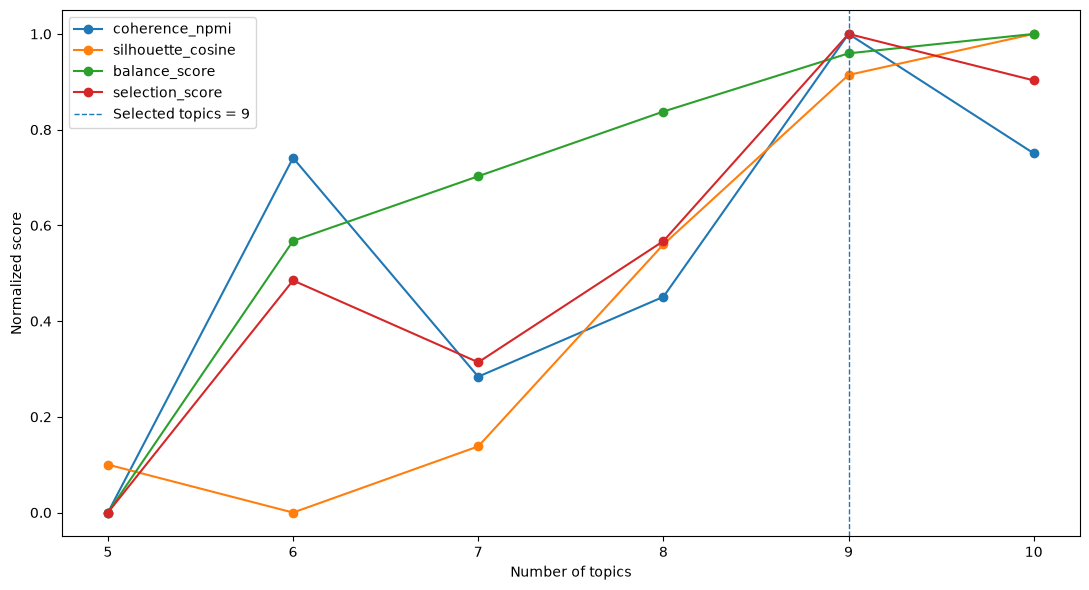

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/sentiment/img/sentiment_bertopic_topic_selection_metrics.png


In [10]:
# ==========================================
# Step 8: Plot BERTopic topic-number selection metrics
# ==========================================

plot_topic_selection_metrics(
    topic_search_results_df,
    SELECTED_N_TOPICS,
    IMG_DIR / "sentiment_bertopic_topic_selection_metrics.png",
)


In [11]:
# ==========================================
# Step 9: Fit BERTopic model with KMeans
# Main discovery on original sentiment documents only
# Uses the selected topic number from the previous cell
# ==========================================

RANDOM_STATE = 42

N_TOPICS = int(globals().get("SELECTED_N_TOPICS", 8))
TOP_N_WORDS = 12


# ------------------------------------------
# Reset old model outputs to avoid stale state
# ------------------------------------------

for variable_name in [
    "topic_model",
    "topics",
    "probabilities",
    "topic_info",
    "topic_distribution",
    "topic_keywords_df",
]:
    if variable_name in globals():
        del globals()[variable_name]


# ------------------------------------------
# BERTopic components
# ------------------------------------------

kmeans_model = KMeans(
    n_clusters=N_TOPICS,
    random_state=RANDOM_STATE,
    n_init=5,
    max_iter=200,
)

bertopic_vectorizer_model = CountVectorizer(
    analyzer="word",
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 1),
    min_df=1,
)

ctfidf_model = ClassTfidfTransformer(
    reduce_frequent_words=True
)

topic_model = BERTopic(
    language="multilingual",
    embedding_model=None,
    umap_model=IdentityDimensionalityReducer(),
    hdbscan_model=kmeans_model,
    vectorizer_model=bertopic_vectorizer_model,
    ctfidf_model=ctfidf_model,
    top_n_words=TOP_N_WORDS,
    calculate_probabilities=False,
    verbose=True,
)


# ------------------------------------------
# Fit BERTopic
# ------------------------------------------

topics, probabilities = topic_model.fit_transform(
    bertopic_docs,
    embeddings=tfidf_svd_embeddings,
)

bertopic_df["topic"] = topics

topic_info = topic_model.get_topic_info()


# ------------------------------------------
# Topic distribution and keywords
# ------------------------------------------

topic_distribution = (
    bertopic_df["topic"]
    .value_counts()
    .sort_index()
    .rename_axis("topic")
    .reset_index(name="documents")
)

topic_distribution["share"] = (
    topic_distribution["documents"] / topic_distribution["documents"].sum()
).round(3)

topic_keywords_rows = []

for topic_id in sorted(bertopic_df["topic"].unique()):
    topic_words = topic_model.get_topic(topic_id)

    if topic_words is None:
        continue

    topic_keywords_rows.append({
        "topic": topic_id,
        "keywords": ", ".join([word for word, score in topic_words]),
    })

topic_keywords_df = pd.DataFrame(topic_keywords_rows)


# ------------------------------------------
# Topic keyword audit
# ------------------------------------------

topic_keyword_tokens = set(
    token
    for keywords in topic_keywords_df["keywords"].fillna("").astype(str)
    for token in keywords.replace(",", " ").split()
)

forbidden_found = sorted(set(bad_tokens) & topic_keyword_tokens)

if forbidden_found:
    raise ValueError(
        f"Forbidden terms still found in BERTopic topic labels: {forbidden_found}"
    )


# ------------------------------------------
# Save outputs
# ------------------------------------------

topic_info_path = OUT_DIR / "sentiment_bertopic_topic_info.csv"
topic_distribution_path = OUT_DIR / "sentiment_bertopic_topic_distribution.csv"
topic_keywords_path = OUT_DIR / "sentiment_bertopic_topic_keywords.csv"
assigned_docs_path = OUT_DIR / "sentiment_bertopic_original_documents_with_topics.csv"

topic_info.to_csv(topic_info_path, index=False, encoding="utf-8-sig")
topic_distribution.to_csv(topic_distribution_path, index=False, encoding="utf-8-sig")
topic_keywords_df.to_csv(topic_keywords_path, index=False, encoding="utf-8-sig")
bertopic_df.to_csv(assigned_docs_path, index=False, encoding="utf-8-sig")

print("BERTopic model fitted")
print("=" * 80)
print(f"Documents used for fitting: {len(bertopic_docs)}")
print(f"Selected/requested number of topics: {N_TOPICS}")
print(f"Discovered topics: {bertopic_df['topic'].nunique()}")
print("Topic keyword audit passed.")

print("\nTopic information:")
print(topic_info)

print("\nTopic distribution:")
print(topic_distribution)

print("\nTopic keywords:")
print(topic_keywords_df)


2026-06-30 04:22:00,256 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-30 04:22:00,257 - BERTopic - Dimensionality - Completed ✓
2026-06-30 04:22:00,258 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 04:22:00,383 - BERTopic - Cluster - Completed ✓
2026-06-30 04:22:00,386 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 04:22:00,427 - BERTopic - Representation - Completed ✓


BERTopic model fitted
Documents used for fitting: 455
Selected/requested number of topics: 9
Discovered topics: 9
Topic keyword audit passed.

Topic information:
   Topic  Count                                     Name  \
0      0     94  0_student_help_administrative_mediation   
1      1     67    1_teacher_professional_teach_educator   
2      2     57            2_duolingo_day_photomath_mooc   
3      3     53       3_ethic_ethical_framework_european   
4      4     53              4_youth_worker_sector_young   
5      5     44                5_child_young_people_game   
6      6     30         6_learner_staff_extremely_unsure   
7      7     29              7_high_public_fear_optimism   
8      8     28         8_positifs_négatifs_sait_premier   

                                                                                                               Representation  \
0                [student, help, administrative, mediation, quote, feedback, task, procedure, support, media

In [12]:
# ==========================================
# Step 10: Inspect BERTopic topics and representative documents
# Main quality check before robustness testing
# ==========================================

from sklearn.metrics.pairwise import cosine_similarity


# ------------------------------------------
# Helper functions
# ------------------------------------------

def get_topic_keywords(topic_id, top_n=12):
    topic_words = topic_model.get_topic(topic_id)

    if topic_words is None:
        return ""

    return ", ".join([word for word, score in topic_words[:top_n]])


def get_representative_docs_for_topic(topic_id, top_n=5):
    topic_indices = np.where(bertopic_df["topic"].values == topic_id)[0]

    if len(topic_indices) == 0:
        return pd.DataFrame()

    topic_embeddings = tfidf_svd_embeddings[topic_indices]
    centroid = kmeans_model.cluster_centers_[topic_id].reshape(1, -1)
    similarities = cosine_similarity(topic_embeddings, centroid).ravel()

    ranked_local_indices = np.argsort(similarities)[::-1][:top_n]
    ranked_global_indices = topic_indices[ranked_local_indices]

    result = bertopic_df.iloc[ranked_global_indices].copy()
    result["representativeness_score"] = similarities[ranked_local_indices]

    selected_columns = [
        "topic",
        "representativeness_score",
        "doc_id",
        "source_type",
        "synthetic_type",
        "bertopic_token_count",
        "bertopic_source_text",
        "bertopic_clean_text",
    ]

    existing_columns = [
        col for col in selected_columns
        if col in result.columns
    ]

    return result[existing_columns]


# ------------------------------------------
# Topic quality overview
# ------------------------------------------

topic_quality_rows = []

for topic_id in sorted(bertopic_df["topic"].unique()):
    topic_subset = bertopic_df[bertopic_df["topic"] == topic_id]

    topic_quality_rows.append({
        "topic": topic_id,
        "documents": len(topic_subset),
        "share": round(len(topic_subset) / len(bertopic_df), 3),
        "keywords": get_topic_keywords(topic_id),
    })

topic_quality_df = pd.DataFrame(topic_quality_rows)

print("Topic quality overview")
print("=" * 80)
print(topic_quality_df)


# ------------------------------------------
# Representative documents
# ------------------------------------------

TOP_N_REPRESENTATIVE_DOCS = 5

for topic_id in sorted(bertopic_df["topic"].unique()):
    print("\n" + "=" * 100)
    print(f"Topic {topic_id}")
    print("=" * 100)
    print("Keywords:")
    print(get_topic_keywords(topic_id))
    print("\nRepresentative documents:")

    print(
        get_representative_docs_for_topic(
            topic_id,
            top_n=TOP_N_REPRESENTATIVE_DOCS,
        )
    )


Topic quality overview
   topic  documents  share                                                                                                                  keywords
0      0         94  0.207                student, help, administrative, mediation, quote, feedback, task, procedure, support, mediator, think, need
1      1         67  0.147  teacher, professional, teach, educator, secondary, experience, focus, leader, profession, literacy, student, pre-service
2      2         57  0.125                       duolingo, day, photomath, mooc, think, class, teacher, know, intention, positive, student, negative
3      3         53  0.116                     ethic, ethical, framework, european, europe, address, agency, guideline, literacy, union, aim, robust
4      4         53  0.116                  youth, worker, sector, young, people, european, expert, space, democratic, social, impact, participation
5      5         44  0.097                                child, young, people, gam

In [13]:
# ==========================================
# Step 11: Load compact local SLM and generate topic phrasing
# This is NOT Causal ML / causal inference.
# AutoModelForCausalLM is only the Hugging Face class for autoregressive text generation.
# The SLM is used only for final topic labels/prototypes.
# ==========================================

LABEL_SLM_MODEL_NAME = os.environ.get(
    "LABEL_SLM_MODEL_NAME",
    "Qwen/Qwen2.5-1.5B-Instruct",
)

LABEL_SLM_MAX_NEW_TOKENS = 180
ENABLE_SLM_REFINEMENT = os.environ.get(
    "ENABLE_SLM_REFINEMENT",
    "1",
).strip().lower() not in {"0", "false", "no"}

SLM_AVAILABLE = False
slm_tokenizer = None
slm_model = None


def extract_json_object(text):
    text = str(text).strip()

    if not text:
        return {}

    text = re.sub(r"^```(?:json)?", "", text.strip(), flags=re.IGNORECASE).strip()
    text = re.sub(r"```$", "", text.strip()).strip()

    try:
        parsed = json.loads(text)
        return parsed if isinstance(parsed, dict) else {}
    except Exception:
        pass

    start_positions = [i for i, char in enumerate(text) if char == "{"]

    for start in start_positions:
        depth = 0
        in_string = False
        escape = False

        for end in range(start, len(text)):
            char = text[end]

            if escape:
                escape = False
                continue

            if char == "\\":
                escape = True
                continue

            if char == '"':
                in_string = not in_string
                continue

            if in_string:
                continue

            if char == "{":
                depth += 1
            elif char == "}":
                depth -= 1

                if depth == 0:
                    candidate = text[start:end + 1]

                    try:
                        parsed = json.loads(candidate)
                        return parsed if isinstance(parsed, dict) else {}
                    except Exception:
                        break

    return {}


if not ENABLE_SLM_REFINEMENT:
    print("SLM refinement disabled by ENABLE_SLM_REFINEMENT=0.")

try:
    from huggingface_hub import login

    hf_token = os.environ.get("HF_TOKEN")

    if hf_token:
        login(token=hf_token)
        print("Authenticated to Hugging Face Hub.")

except Exception as e:
    print(f"Warning: Hugging Face login skipped: {e}")


try:
    if not ENABLE_SLM_REFINEMENT:
        raise RuntimeError("SLM refinement disabled")

    from transformers import AutoModelForCausalLM as AutoGenerativeLM
    from transformers import AutoTokenizer

    if torch is None:
        raise ImportError("torch is not available")

    slm_tokenizer = AutoTokenizer.from_pretrained(
        LABEL_SLM_MODEL_NAME,
        trust_remote_code=True,
    )

    slm_model = AutoGenerativeLM.from_pretrained(
        LABEL_SLM_MODEL_NAME,
        dtype=(torch.float16 if torch.cuda.is_available() else torch.float32),
        device_map="auto" if torch.cuda.is_available() else None,
        trust_remote_code=True,
    )

    if not torch.cuda.is_available():
        slm_model = slm_model.to("cpu")

    slm_model.eval()
    SLM_AVAILABLE = True

    print("SLM loaded:", LABEL_SLM_MODEL_NAME)

except Exception as e:
    SLM_AVAILABLE = False

    print("Warning: SLM could not be loaded.")
    print("Reason:", e)


def slm_generate(prompt, max_new_tokens=LABEL_SLM_MAX_NEW_TOKENS):
    if not SLM_AVAILABLE:
        raise RuntimeError("SLM generation requested but SLM_AVAILABLE=False.")

    messages = [
        {
            "role": "system",
            "content": (
                "You are a precise topic-modelling assistant. "
                "Return exactly one valid JSON object. "
                "Do not use Markdown. Do not explain."
            ),
        },
        {
            "role": "user",
            "content": prompt,
        },
    ]

    if hasattr(slm_tokenizer, "apply_chat_template"):
        chat_text = slm_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    else:
        chat_text = prompt

    encoded = slm_tokenizer(
        chat_text,
        return_tensors="pt",
        truncation=True,
        max_length=4096,
    )

    model_device = next(slm_model.parameters()).device
    encoded = {
        key: value.to(model_device)
        for key, value in encoded.items()
    }

    input_ids = encoded["input_ids"]
    attention_mask = encoded.get(
        "attention_mask",
        torch.ones_like(input_ids),
    )

    with torch.no_grad():
        output_ids = slm_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=slm_tokenizer.eos_token_id,
            eos_token_id=slm_tokenizer.eos_token_id,
        )

    generated_ids = output_ids[0][input_ids.shape[-1]:]
    text = slm_tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
    ).strip()

    if not text:
        raise RuntimeError("SLM returned an empty response.")

    return text


def fallback_topic_label(keywords, max_words=8):
    tokens = [
        token.strip()
        for token in str(keywords).replace(",", " ").split()
        if token.strip()
    ]

    return " ".join(tokens[:max_words]).title()


def build_representative_docs_df(top_n=5):
    representative_rows = []

    for topic_id in sorted(bertopic_df["topic"].unique()):
        topic_docs = get_representative_docs_for_topic(
            topic_id,
            top_n=top_n,
        )

        if len(topic_docs) == 0:
            continue

        topic_docs = topic_docs.copy()
        topic_docs["representative_rank"] = range(1, len(topic_docs) + 1)
        representative_rows.append(topic_docs)

    if not representative_rows:
        return pd.DataFrame()

    return pd.concat(representative_rows, ignore_index=True)


def generate_slm_topic_phrases(
    topic_info_df,
    topic_keyword_df,
    representative_docs_df,
    output_dir,
    output_prefix,
    corpus_description,
    max_docs_per_topic=4,
):
    topic_rows = []

    for _, topic_row in topic_info_df.sort_values("topic").iterrows():
        topic_id = int(topic_row["topic"])

        keyword_match = topic_keyword_df[
            topic_keyword_df["topic"].eq(topic_id)
        ]

        if len(keyword_match) > 0:
            keywords = str(keyword_match.iloc[0].get("keywords", ""))
        else:
            keywords = str(topic_row.get("keywords", ""))

        topic_docs = representative_docs_df[
            representative_docs_df["topic"].eq(topic_id)
        ].head(max_docs_per_topic)

        snippet_lines = []

        for doc_index, (_, doc_row) in enumerate(topic_docs.iterrows(), start=1):
            text = str(
                doc_row.get(
                    "bertopic_source_text",
                    doc_row.get("bertopic_clean_text", ""),
                )
            )

            text = re.sub(r"\s+", " ", text).strip()
            snippet_lines.append(f"{doc_index}. {text[:700]}")

        representative_text = "\n".join(snippet_lines)

        if not SLM_AVAILABLE:
            label = fallback_topic_label(keywords)
            prototype = f"Sentiment topic about {label}."

            topic_rows.append({
                "topic": topic_id,
                "topic_label": label,
                "topic_prototype": prototype,
                "sentiment_dimension": "",
                "is_coherent": "",
                "artifact_topic": "",
                "merge_hint": "",
                "keywords": keywords,
                "slm_raw_response": "SLM unavailable; fallback label used.",
            })
            continue

        label_prompt = f"""
You are labelling topics from a public-opinion / sentiment corpus.

Corpus description:
{corpus_description}

Topic id: {topic_id}
Topic keywords:
{keywords}

Representative chunks:
{representative_text}

Return exactly one JSON object using this schema:
{{
  "label": "specific sentiment topic label, 5 to 12 words",
  "prototype": "one clear sentence describing what people are expressing in this topic",
  "sentiment_dimension": "short dimension such as trust, concern, optimism, education impact, employment risk, assessment anxiety, governance demand, social impact",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": ""
}}

Label rules:
- Do NOT use generic labels such as "AI Sentiment", "Public Opinion", "Technology Views", or "General Discussion".
- The label must mention the concrete concern, benefit, population, institution, or setting.
- Prefer labels like:
  "Student Assessment Anxiety Around Generative AI"
  "Teacher Adaptation and Classroom AI Use"
  "Youth Employment Concerns About Automation"
  "Public Trust and Governance Expectations for AI"
- If the topic is about education, say what part: assessment, teachers, students, learning, curriculum, classroom use.
- If the topic is about risks, say what risk: job loss, cheating, privacy, misinformation, social inequality, dependency.
- If the topic is about benefits, say what benefit: productivity, access, creativity, learning support, inclusion.
- Use double quotes.
- Use true or false, not True or False.
- Do not include Markdown.
- Do not include explanations outside JSON.
""".strip()

        slm_raw = slm_generate(
            label_prompt,
            max_new_tokens=LABEL_SLM_MAX_NEW_TOKENS,
        )

        slm_json = extract_json_object(slm_raw)

        print(f"\nTopic {topic_id} SLM raw response:")
        print(slm_raw[:500])

        if not slm_json:
            raise RuntimeError(
                f"Could not parse SLM JSON for topic {topic_id}. Raw response:\n{slm_raw}"
            )

        label = str(slm_json.get("label", "")).strip()
        prototype = str(slm_json.get("prototype", "")).strip()

        if not label:
            label = fallback_topic_label(keywords)

        if not prototype:
            prototype = f"Sentiment topic about {fallback_topic_label(keywords)}."

        topic_rows.append({
            "topic": topic_id,
            "topic_label": label,
            "topic_prototype": prototype,
            "sentiment_dimension": str(slm_json.get("sentiment_dimension", "")).strip(),
            "is_coherent": slm_json.get("is_coherent", ""),
            "artifact_topic": slm_json.get("artifact_topic", ""),
            "merge_hint": str(slm_json.get("merge_hint", "")).strip(),
            "keywords": keywords,
            "slm_raw_response": slm_raw,
        })

    topic_phrases_df = pd.DataFrame(topic_rows)

    topic_phrases_df.to_csv(
        output_dir / f"{output_prefix}_slm_topic_phrases.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return topic_phrases_df


# ------------------------------------------
# Build representative documents for SLM labels
# ------------------------------------------

topic_representative_docs_df = build_representative_docs_df(top_n=5)

topic_representative_docs_df.to_csv(
    OUT_DIR / "sentiment_bertopic_representative_documents.csv",
    index=False,
    encoding="utf-8-sig",
)


# ------------------------------------------
# Generate SLM topic phrases
# ------------------------------------------

topic_phrases_df = generate_slm_topic_phrases(
    topic_quality_df,
    topic_keywords_df,
    topic_representative_docs_df,
    OUT_DIR,
    "sentiment_bertopic",
    corpus_description=(
        "Sentiment and public-opinion chunks about AI, education, youth, "
        "employment, society, trust, risks, and perceived benefits."
    ),
)


topic_label_map = dict(
    zip(topic_phrases_df["topic"], topic_phrases_df["topic_label"])
)

topic_prototype_map = dict(
    zip(topic_phrases_df["topic"], topic_phrases_df["topic_prototype"])
)

bertopic_df["topic_label"] = bertopic_df["topic"].map(topic_label_map)
bertopic_df["topic_prototype"] = bertopic_df["topic"].map(topic_prototype_map)

phrase_columns = [
    "topic_label",
    "topic_prototype",
    "sentiment_dimension",
    "is_coherent",
    "artifact_topic",
    "merge_hint",
]

topic_quality_df = topic_quality_df.drop(
    columns=[col for col in phrase_columns if col in topic_quality_df.columns],
    errors="ignore",
)

topic_quality_df = topic_quality_df.merge(
    topic_phrases_df[
        [
            "topic",
            "topic_label",
            "topic_prototype",
            "sentiment_dimension",
            "is_coherent",
            "artifact_topic",
            "merge_hint",
        ]
    ],
    on="topic",
    how="left",
)

topic_quality_df.to_csv(
    OUT_DIR / "sentiment_bertopic_topic_info_with_slm_phrases.csv",
    index=False,
    encoding="utf-8-sig",
)

bertopic_df.to_csv(
    OUT_DIR / "sentiment_bertopic_original_documents_with_slm_topic_phrases.csv",
    index=False,
    encoding="utf-8-sig",
)

print("SLM topic phrases complete")
print("Saved:")
print(OUT_DIR / "sentiment_bertopic_slm_topic_phrases.csv")
print(OUT_DIR / "sentiment_bertopic_topic_info_with_slm_phrases.csv")
print(OUT_DIR / "sentiment_bertopic_original_documents_with_slm_topic_phrases.csv")

print(
    topic_phrases_df[
        [
            "topic",
            "topic_label",
            "topic_prototype",
            "sentiment_dimension",
            "is_coherent",
            "artifact_topic",
            "merge_hint",
        ]
    ]
)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Authenticated to Hugging Face Hub.


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

SLM loaded: Qwen/Qwen2.5-1.5B-Instruct

Topic 0 SLM raw response:
```json
{
  "label": "Concern Over AI Usage in Education",
  "prototype": "Some educators and students express concerns about the potential misuse of AI in educational settings.",
  "sentiment_dimension": "concern",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": ""
}
```

Topic 1 SLM raw response:
```json
{
  "label": "Teacher Adaptation and Classroom AI Use",
  "prototype": "Teachers are adapting to new AI tools in classrooms.",
  "sentiment_dimension": "education impact",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": ""
}
```

Topic 2 SLM raw response:
```json
{
  "label": "Impact of Learning Experience on Knowledge and Perceptions of AI",
  "prototype": "Participants discussed the impact of the professional learning experience on their understanding of AI.",
  "sentiment_dimension": "education impact",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": ""
}
```

To

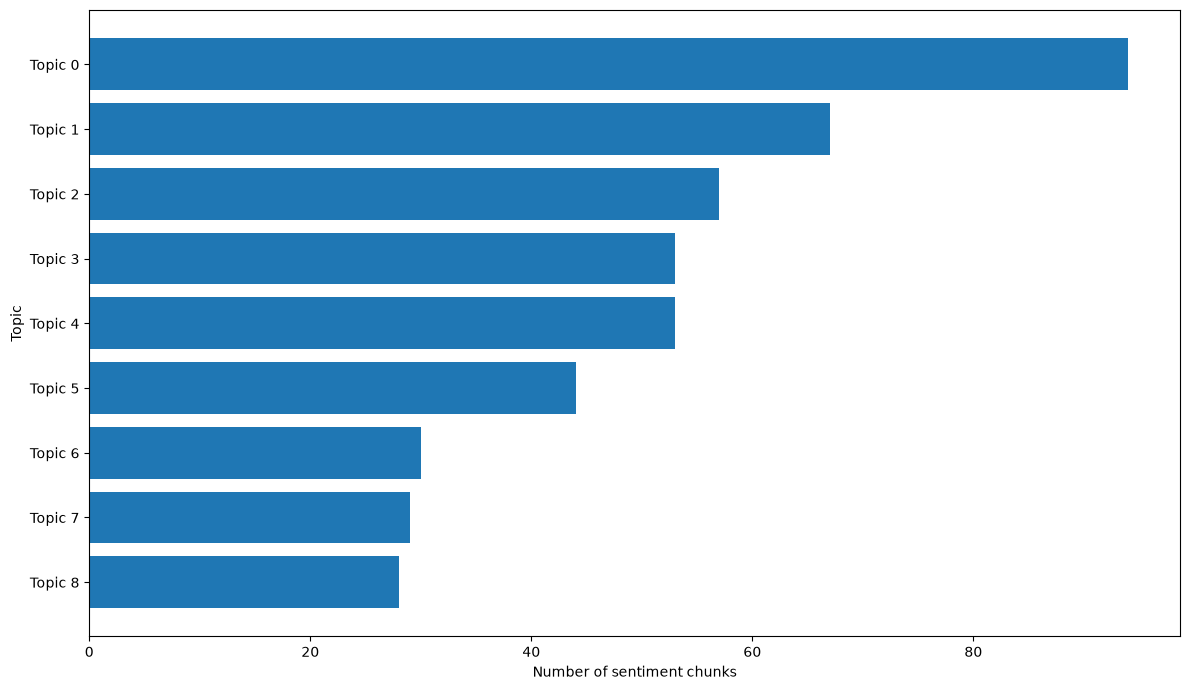

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/sentiment/img/sentiment_bertopic_original_topic_distribution.png


In [14]:
# ==========================================
# Step 12: Plot BERTopic original topic distribution
# ==========================================

plot_topic_distribution(
    topic_quality_df,
    IMG_DIR / "sentiment_bertopic_original_topic_distribution.png",
    topic_keyword_df=topic_keywords_df,
    topic_phrase_df=topic_phrases_df if "topic_phrases_df" in globals() else None,
    xlabel="Number of sentiment chunks",
)


In [15]:
# ==========================================
# Step 13: Synthetic robustness report
# Synthetic data is used only for validation
# ==========================================

from sklearn.metrics.pairwise import cosine_similarity


if synthetic_tfidf_svd_embeddings is None or len(synthetic_bertopic_df) == 0:
    print("No synthetic documents available for robustness checks.")
else:
    # ------------------------------------------
    # Assign synthetic documents to existing topics
    # ------------------------------------------

    synthetic_topics = kmeans_model.predict(synthetic_tfidf_svd_embeddings)

    synthetic_bertopic_df = synthetic_bertopic_df.copy()
    synthetic_bertopic_df["assigned_topic"] = synthetic_topics


    # ------------------------------------------
    # Confidence as similarity to assigned topic centroid
    # ------------------------------------------

    assigned_centroids = kmeans_model.cluster_centers_[synthetic_topics]

    synthetic_similarities = []

    for i in range(len(synthetic_tfidf_svd_embeddings)):
        similarity = cosine_similarity(
            synthetic_tfidf_svd_embeddings[i].reshape(1, -1),
            assigned_centroids[i].reshape(1, -1),
        )[0, 0]

        synthetic_similarities.append(similarity)

    synthetic_bertopic_df["topic_similarity"] = synthetic_similarities


    # ------------------------------------------
    # Compare original and synthetic topic distributions
    # ------------------------------------------

    original_topic_distribution = (
        bertopic_df["topic"]
        .value_counts()
        .sort_index()
        .rename_axis("topic")
        .reset_index(name="original_documents")
    )

    synthetic_topic_distribution = (
        synthetic_bertopic_df["assigned_topic"]
        .value_counts()
        .sort_index()
        .rename_axis("topic")
        .reset_index(name="synthetic_documents")
    )

    synthetic_robustness_df = original_topic_distribution.merge(
        synthetic_topic_distribution,
        on="topic",
        how="outer",
    ).fillna(0)

    synthetic_robustness_df["original_share"] = (
        synthetic_robustness_df["original_documents"]
        / synthetic_robustness_df["original_documents"].sum()
    ).round(3)

    synthetic_robustness_df["synthetic_share"] = (
        synthetic_robustness_df["synthetic_documents"]
        / synthetic_robustness_df["synthetic_documents"].sum()
    ).round(3)

    synthetic_robustness_df["share_difference"] = (
        synthetic_robustness_df["synthetic_share"]
        - synthetic_robustness_df["original_share"]
    ).round(3)

    synthetic_robustness_df = synthetic_robustness_df.merge(
        topic_keywords_df,
        on="topic",
        how="left",
    )

    if "topic_phrases_df" in globals():
        phrase_columns = [
            col for col in [
                "topic",
                "topic_label",
                "topic_prototype",
                "sentiment_dimension",
            ]
            if col in topic_phrases_df.columns
        ]

        if len(phrase_columns) > 1:
            synthetic_robustness_df = synthetic_robustness_df.merge(
                topic_phrases_df[phrase_columns],
                on="topic",
                how="left",
            )


    # ------------------------------------------
    # Low-confidence synthetic assignments
    # ------------------------------------------

    LOW_CONFIDENCE_THRESHOLD = synthetic_bertopic_df["topic_similarity"].quantile(0.10)

    low_confidence_synthetic_df = synthetic_bertopic_df[
        synthetic_bertopic_df["topic_similarity"] <= LOW_CONFIDENCE_THRESHOLD
    ].copy()


    # ------------------------------------------
    # Save outputs
    # ------------------------------------------

    synthetic_assignments_path = OUT_DIR / "sentiment_bertopic_synthetic_assignments.csv"
    synthetic_robustness_path = OUT_DIR / "sentiment_bertopic_synthetic_robustness_report.csv"

    synthetic_bertopic_df.to_csv(
        synthetic_assignments_path,
        index=False,
        encoding="utf-8-sig",
    )

    synthetic_robustness_df.to_csv(
        synthetic_robustness_path,
        index=False,
        encoding="utf-8-sig",
    )


    # ------------------------------------------
    # Display concise report
    # ------------------------------------------

    print("Synthetic robustness report")
    print("=" * 80)
    print("Synthetic documents were assigned to existing original-data topics.")
    print("They were not used to fit the final topic model.")

    print("\nOriginal vs synthetic topic distribution:")
    print(
        synthetic_robustness_df[[
            "topic",
            "original_documents",
            "synthetic_documents",
            "original_share",
            "synthetic_share",
            "share_difference",
            "keywords",
        ]]
    )

    print("\nSynthetic similarity to assigned topic centroid:")
    print(
        synthetic_bertopic_df["topic_similarity"]
        .describe()
        .to_frame("topic_similarity")
    )

    print(f"\nLow-confidence synthetic examples: {len(low_confidence_synthetic_df)}")
    print(
        low_confidence_synthetic_df[[
            "assigned_topic",
            "topic_similarity",
            "doc_id",
            "source_type",
            "synthetic_type",
            "bertopic_clean_text",
        ]].head(20)
    )

    print("\nSaved synthetic robustness outputs:")
    print(synthetic_assignments_path)
    print(synthetic_robustness_path)


Synthetic robustness report
Synthetic documents were assigned to existing original-data topics.
They were not used to fit the final topic model.

Original vs synthetic topic distribution:
   topic  original_documents  synthetic_documents  original_share  synthetic_share  share_difference  \
0      0                  94                 16.0           0.207            0.079            -0.128   
1      1                  67                  0.0           0.147            0.000            -0.147   
2      2                  57                 24.0           0.125            0.119            -0.006   
3      3                  53                 23.0           0.116            0.114            -0.002   
4      4                  53                 32.0           0.116            0.158             0.042   
5      5                  44                  0.0           0.097            0.000            -0.097   
6      6                  30                 40.0           0.066            0.198  

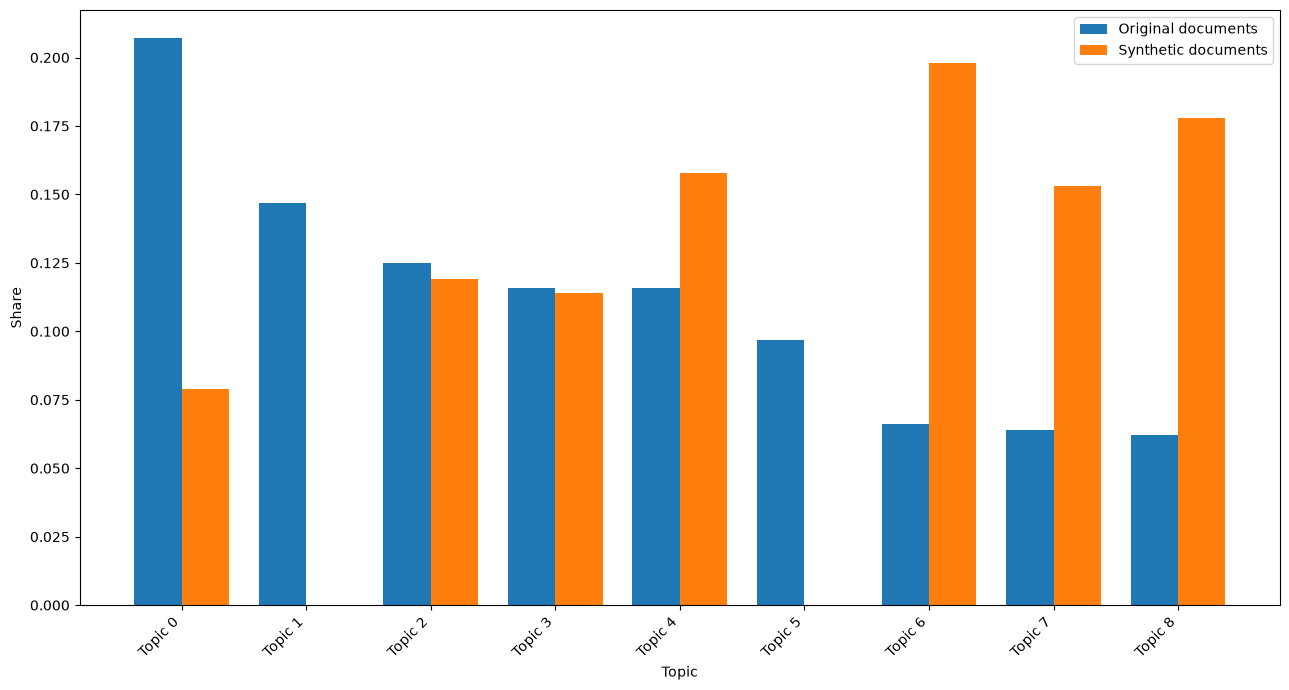

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/sentiment/img/sentiment_bertopic_original_vs_synthetic_distribution.png


In [16]:
# ==========================================
# Step 14: Plot BERTopic original vs synthetic topic distribution
# ==========================================

if "synthetic_robustness_df" not in globals():
    print("synthetic_robustness_df not found. Run the synthetic robustness cell first.")

else:
    plot_original_vs_synthetic_distribution(
        synthetic_robustness_df,
        IMG_DIR / "sentiment_bertopic_original_vs_synthetic_distribution.png",
        topic_keyword_df=topic_keywords_df,
        topic_phrase_df=topic_phrases_df if "topic_phrases_df" in globals() else None,
    )


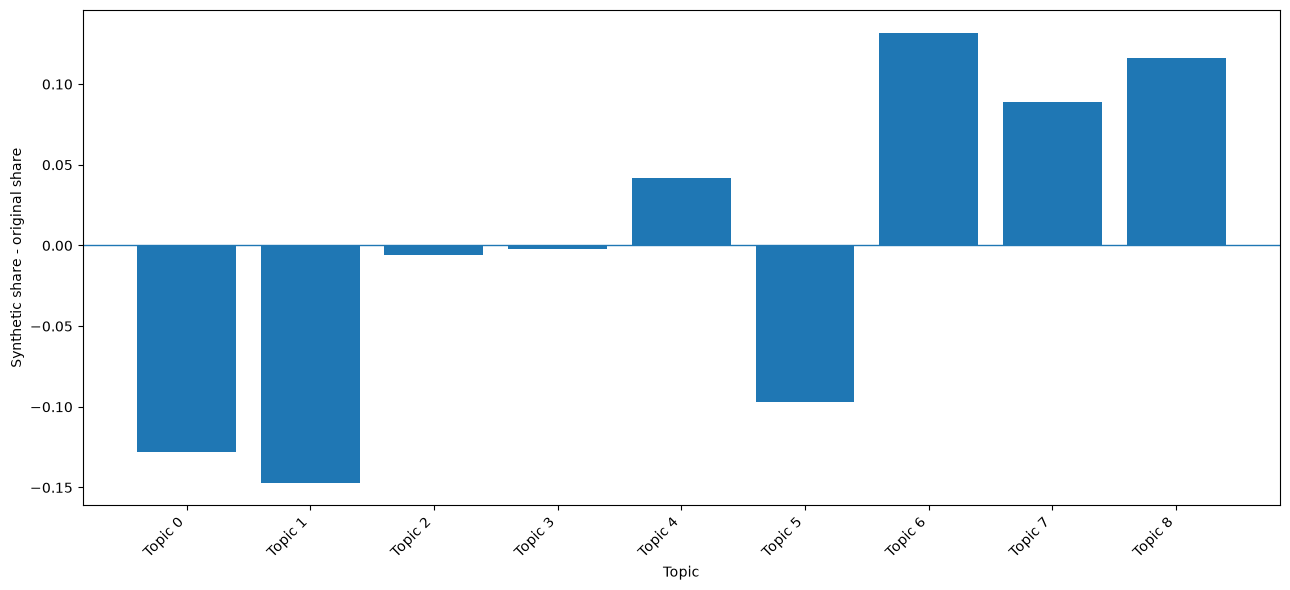

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/sentiment/img/sentiment_bertopic_synthetic_share_difference.png


In [17]:
# ==========================================
# Step 15: Plot BERTopic synthetic-original share difference
# ==========================================

if "synthetic_robustness_df" not in globals():
    print("synthetic_robustness_df not found. Run the synthetic robustness cell first.")

else:
    plot_synthetic_share_difference(
        synthetic_robustness_df,
        IMG_DIR / "sentiment_bertopic_synthetic_share_difference.png",
        topic_keyword_df=topic_keywords_df,
        topic_phrase_df=topic_phrases_df if "topic_phrases_df" in globals() else None,
    )


In [18]:
# ==========================================
# Step 16: Review SLM topic phrases
# SLM-generated phrases replace the old keyword-only labels.
# ==========================================

if "topic_phrases_df" in globals():
    print("Sentiment BERTopic SLM topic phrases:")
    print(
        topic_phrases_df[
            [
                "topic",
                "topic_label",
                "topic_prototype",
                "sentiment_dimension",
                "is_coherent",
                "artifact_topic",
                "merge_hint",
            ]
        ]
    )

    print("Saved:")
    print(OUT_DIR / "sentiment_bertopic_slm_topic_phrases.csv")
    print(OUT_DIR / "sentiment_bertopic_topic_info_with_slm_phrases.csv")
    print(OUT_DIR / "sentiment_bertopic_original_documents_with_slm_topic_phrases.csv")

else:
    print("topic_phrases_df not found. Run the SLM topic phrasing cell first.")


Sentiment BERTopic SLM topic phrases:
   topic                                                       topic_label  \
0      0                                Concern Over AI Usage in Education   
1      1                           Teacher Adaptation and Classroom AI Use   
2      2  Impact of Learning Experience on Knowledge and Perceptions of AI   
3      3                  Ethics Framework Development for AI in Education   
4      4                         Concerns and Risks Around AI in Education   
5      5                             Concern Over AI Risks and Social Harm   
6      6                   Concerns Over GenAI Implementation in Education   
7      7                              public opinion on AI fears and hopes   
8      8                                Concern over AI Risks and Benefits   

                                                                                                                                                                topic_prototype  \
0 